<b><font size="6"> Cars 4 You: Predicting Car Values with ML </font></b><br><br>

`Group 40`

Ana Macedo (20250405)<br>
Catarina Mendinhas (20250422)<br>
Lourenço Silva (20250453)<br>
Maria Fonseca (20250380)<br>

### <font color= '#BFD72F'>**Methodology** </font><a class="anchor" id='toc'></a>

- [1. Abstract](#1)
- [2. Import Libraries](#2)
- [3. Metadata](#3)
- [4. Import Datasets](#4)
    - [4.1 Define new index](#4_1)
- [5. Data Preprocessing](#5)
    - [5.1 Types Correction](#5_1)
        - [5.1.1 Year and previousOwners columns correction](#5_1_1)
        - [5.1.2 hasDamage Column Correction](#5_1_2)
    - [5.2 Categorical Features correction](#5_2)
        - [5.2.1 Creating the Correction Function](#5_2_1)
        - [5.2.2 Correct the values](#5_2_2)
        - [5.2.3 Check corrections](#5_2_3)
    - [5.3 Outliers](#5_3)
        - [5.3.1 Outliers Analysis](#5_3_1)
        - [5.3.2 First Outliers Treatment](#5_3_2)
    - [5.4 Data Partition](#5_4)
    - [5.5 Continue Outliers Treatment](#5_5)
    - [5.6 Feature Engineering without using median, mean or mode](#5_6)
    - [5.7 Feature Engineering considering mean and other calculations](#5_7)
    - [5.8 Missing Values](#5_8)
        - [5.8.1 Missing Values Analysis](#5_8_1)
        - [5.8.2 Treat Numeric Missing Values with the median](#5_8_2)
        - [5.8.3 Treat Categorical Missing Values with the mode](#5_8_3)
    - [5.9 Encoding](#5_9)
    - [5.10 Scaling Features](#5_10)
    - [5.11 KNN Imputer](#5_11)
    - [5.12 Save the Processed Data](#5_12)
- [6 End of The Notebook](#6)


<a class="anchor" id="1">

# **1. Abstract**

[Back to TOC](#toc)
</a>

This project aims to develop a predictive model capable of estimating car prices based on their characteristics, using the Cars 4 You dataset. The goal is to support the company’s evaluation process by introducing an automated solution that accelerates car assessments and improves overall efficiency.

The current phase of the project focuses on data preprocessing, which involves cleaning, transforming, and preparing the dataset for modeling. This includes handling missing values, encoding categorical features, scaling numerical features, and ensuring data consistency across all attributes. These steps are essential to create a reliable and structured dataset that will serve as the foundation for the subsequent modeling phase.

<a class="anchor" id="2">

# **2. Import Libraries**

[Back to TOC](#toc)
</a>


The following libraries will help us develop the analyses and model for this project. Pandas and NumPy provide efficient tools for data manipulation, cleaning and numerical computations. Matplotlib and Seaborn are used to create clear and informative visualizations. Scikit-learn offers a range of Machine Learning tools for model training, splitting the data and evaluating model performance. Then, os, math and ceil are imported to support file management and mathematical operations. SequenceMatcher assists in detecting string similarity for text preprocessing. OneHotEncoder, MinMaxScaler and StandardScaler are used to transform categorical and numerical features into model-ready formats. KNNImputer is applied to handle missing data using nearest-neighbour estimates.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import math
import sys

from math import ceil
from difflib import SequenceMatcher
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, MinMaxScaler, StandardScaler
from sklearn.impute import KNNImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

# Load Created Functions
#from functions import *

# Set random seed for reproducibility
np.random.seed(40111) 

<a class="anchor" id="3">

# **3. Metadata**

[Back to TOC](#toc)
</a>

Understanding the features is essential to interpret the data correctly and conduct the subsequent analysis and modeling steps. This section provides a brief description of each feature in the dataset, explaining its meaning and type.

**carID:** An attribute that contains an identifier for each car.

**Brand:** The car's main brand (e.g., Ford, Toyota).

**model:** The car model.

**year:** The year of registration of the car.

**price:** The car's price when purchased by Cars 4 You (in £).

**transmission:** The car's type of transmission.

**mileage:** The total reported distance travelled by the car (in miles).

**tax:** The amount of road tax (in £) that, in 2020, was applicable to the car in question.

**fuelType:** The type of fuel used by the car (Diesel, Petrol, Hybrid, Electric).

**mpg:** The car's consumption of fuel expressed in average miles per gallon.

**engineSize:** Size of the engine in liters (Cubic Decimeters).

**paintQuality%** The mechanic’s assessment of the cars’ overall paint quality and hull integrity (filled by the mechanic during evaluation). 

**previousOwner:** Number of previous registered owners of the vehicle.

**hasDamage:** Boolean marker filled by the seller at the time of registration stating whether the car is damaged or not.

<a class="anchor" id="4">

# **4. Import Datasets**

[Back to TOC](#toc)
</a>

Here, we are importing with pd.read_csv() the files to start our project and converting them into Pandas DataFrames. CarID was set to index since it's the unique identifier in all data sets.

In [2]:
sample = pd.read_csv('../../data/sample_submission.csv')
train = pd.read_csv('../../data/train.csv')
test = pd.read_csv('../../data/test.csv')

<a class="anchor" id="4">

## **4.1 Define new index**

[Back to TOC](#toc)
</a>

For all partitions we will assign the "carID" column as the index, as it represents the number identifier for each individual car.

In [3]:
sample.set_index('carID', inplace = True)
train.set_index('carID', inplace = True)
test.set_index('carID', inplace = True)

<a class="anchor" id="5">

# **5. Data Preprocessing**

[Back to TOC](#toc)
</a>

<a class="anchor" id="5_1">

## **5.1** Types Correction
[Back to TOC](#toc)
</a>

In the EDA phase we noticed some inconsistencies in the features types. We will decide what to do with these errors and correct them.

Before starting, we will create a copy of the original dataframes to avoid any unwanted changes to the original data.

In [4]:
train = train.copy()
test = test.copy()

We are going to decide how to correct the data and this decision will be based on the percentage of incorrect values.

We will analyse the train dataset and take action in both train and test datasets.

We had previously identified that there are float values in the columns `Year`, `hasDamage` and `previousOwners` that should be integers as they represent discrete variables and a boolean in the case of hasDamage.

<a class="anchor" id="5_1_1">

### **5.1.1** Year and previousOwners columns correction
[Back to TOC](#toc)
</a>

In [5]:
# percentage of float values in year and previousOwners columns
num_incorrect_year = (train['year'] % 1 != 0).sum() / train.shape[0] * 100
print(f'Percentage of incorrect values in year column: {num_incorrect_year:.2f}%')

num_incorrect_previousOwners = (train['previousOwners'] % 1 != 0).sum() / train.shape[0] * 100
print(f'Percentage of incorrect values in previousOwners column: {num_incorrect_previousOwners:.2f}%')


Percentage of incorrect values in year column: 2.91%
Percentage of incorrect values in previousOwners column: 3.01%


We decided to round all values of the features because the percentage of incorrect values is close to 3% (minimal). We chose rounding over flooring or ceiling because rounding gives the value that is mathematically closest to the original number, therefore minimizing bias and error.

In [6]:
# train[['year', 'previousOwners']] = train[['year', 'previousOwners']].round(0).astype('Int64')

In [7]:
def round_half_up(df, cols):
    """Rounds numeric values: values with decimal part >= 0.5 go up, others go down."""

    for col in cols:
        df[col] = np.floor(df[col] + 0.5).astype('Int64')
    return df

train = round_half_up(train, ['year', 'previousOwners'])
test = round_half_up(test, ['year', 'previousOwners'])

<a class="anchor" id="5_1_2">

### **5.1.2** hasDamage Column Correction
[Back to TOC](#toc)
</a>

In the HasDamage column, we only have 0's and NaN values. We decided to fill the NaN's with 1's to create boolean features by assuming that NaN values mean that there is damage to the car. Our rationale was that the customer prefers to ommit when there is damage to the car to raise its value. 

We agreed that this change was urgent and, because of that, it was done before the splitting.

In [8]:
train['hasDamage']=train['hasDamage'].astype('Int64')
test['hasDamage']=test['hasDamage'].astype('Int64')

train['hasDamage']=train['hasDamage'].fillna(1)
test['hasDamage']=test['hasDamage'].fillna(1)

<a class="anchor" id="5_2">

## **5.2** Categorical Features correction

[Back to TOC](#toc)

We had identified earlier that the categorical features present a lot of misspellings. We will address that here.

<a class="anchor" id="5_2_1">

### **5.2.1** Creating the Correction Function

[Back to TOC](#toc)

We start by creating a function that corrects these strange values by using the library difflib.

In [9]:
from difflib import SequenceMatcher

# Function to calculate similarity between two strings
def similar(a, b):
    """
    Checks similarity between two strings using SequenceMatcher.
    It calculates the percentage of equal characters between both inputs.
    """

    return SequenceMatcher(None, a, b).ratio()


# Function to clean categorical column using difflib
def clean_with_diff(
    df, column,
    threshold_short,
    threshold_long 
):
    """
    Groups similar values and replaces them by the most frequent (mode).
    threshold_short: similarity threshold when both strings have <= 5 chars
    threshold_long: similarity threshold otherwise
    """
    # Get unique values in the column
    values = df[column].dropna().unique()
    groups = []
    used = set()
    
    # Group similar values
    for v in values:
        if v in used:
            continue
        
        # Start a new group
        group = [v]
        used.add(v)
        
        # Compare with other values
        for other in values:
            if other in used:
                continue

            # Choose the thresholds based on length
            if len(v) <= 5 and len(other) <= 5:
                threshold = threshold_short
            else:
                threshold = threshold_long

            # Check similarity. If similar, add to group.
            if similar(v.lower(), other.lower()) >= threshold:
                group.append(other)
                used.add(other)

        # Append the group to the list of groups
        groups.append(group)
    
    # Create mapping for each group and replace values with mode
    mapping = {}
    for group in groups:
        moda = df[df[column].isin(group)][column].mode()[0]
        for item in group:
            mapping[item] = moda
    
    df[column] = df[column].map(mapping).fillna(df[column])
    
    return df


<a class="anchor" id="5_2_2">

### **5.2.2** Correct the values

[Back to TOC](#toc)

Now we are able to correct the values by calling the function. We have tested the corrections with different thresholds for all variables and landed on these to get the best results. 

In [10]:
# Correct 'Brand' column
clean_with_diff(train, 'Brand', threshold_short=0.6, threshold_long=0.6)
clean_with_diff(test, 'Brand', threshold_short=0.5, threshold_long=0.6)

# Correct 'transmission' column
clean_with_diff(train, 'transmission', threshold_short=0.7, threshold_long=0.7)
clean_with_diff(test, 'transmission', threshold_short=0.7, threshold_long=0.7)

# Correct 'model' column
clean_with_diff(train, 'model', threshold_short=0.70, threshold_long=0.90)
clean_with_diff(test, 'model', threshold_short=0.70, threshold_long=0.90)

# Correct 'fuelType' column
clean_with_diff(train, 'fuelType', threshold_short=0.8, threshold_long=0.8)
clean_with_diff(test, 'fuelType', threshold_short=0.8, threshold_long=0.8)

# The output shows us a part of the dataframe after the values corrections

,Brand,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,
89856,Hyundai,I10,2023,Automatic,30700.000000,Petrol,205.0,41.5,1.6,61.0,3,0
106581,VW,Tiguan,2017,Semi-Auto,-48190.655673,Petrol,150.0,38.2,2.0,60.0,2,0
80886,BMW,2 Series,2016,Automatic,36792.000000,Petrol,125.0,51.4,1.5,94.0,2,0
100174,Opel,Grandland X,2019,Manual,5533.000000,Petrol,145.0,44.1,1.2,77.0,1,0
81376,BMW,1 Series,2019,Semi-Auto,9058.000000,Diesel,150.0,51.4,2.0,45.0,4,0
...,...,...,...,...,...,...,...,...,...,...,...,...
105775,VW,Tiguan,2017,Manual,27575.000000,Petrol,145.0,46.3,1.4,94.0,1,0
81363,BMW,X2,2020,Automatic,1980.000000,Petrol,145.0,34.0,2.0,39.0,3,0
76833,Audi,Q5,2019,Semi-Auto,8297.000000,Diesel,145.0,38.2,2.0,88.0,4,0


<a class="anchor" id="5_2_3">

### **5.2.3** Check corrections

[Back to TOC](#toc)

In [11]:
corrected_columns = ['Brand', 'transmission', 'model', 'fuelType']

for column in corrected_columns:
    unique_values_train = train[column].unique()
    unique_values_test = test[column].unique()
    print(f"Unique values on the column '{column}' (train): {unique_values_train}")
    print('')
    print(f"Unique values on the column '{column}' (test): {unique_values_test}")
    print('')
    print('-----------------------------------')
    print('')

Unique values on the column 'Brand' (train): ['VW' 'Toyota' 'Audi' 'Ford' 'BMW' 'Skoda' 'Opel' 'Mercedes' 'Hyundai' nan]

Unique values on the column 'Brand' (test): ['Hyundai' 'VW' 'BMW' 'Opel' 'Ford' 'Mercedes' 'Skoda' 'Toyota' 'Audi' nan]

-----------------------------------

Unique values on the column 'transmission' (train): ['Semi-Auto' 'Manual' 'Automatic' nan 'unknown' 'Other']

Unique values on the column 'transmission' (test): ['Automatic' 'Semi-Auto' 'Manual' 'unknown' nan 'Other']

-----------------------------------

Unique values on the column 'model' (train): [' Golf' ' Yaris' ' Q2' ' Fiesta' ' 2 Series' ' 3 Series' ' A3' ' Octavia'
 ' Passat' ' Focus' ' Insignia' ' A Class' ' Q3' ' Fabia' ' Ka+'
 ' GLC Class' ' I10' ' C Class' ' Polo' ' E Class' ' Q5' ' Up' ' C-HR'
 ' Mokka X' ' Corsa' ' Astra' ' TT' ' 5 Series' ' Aygo' ' 4 Series' ' SLK'
 ' Viva' ' T-Roc' ' EcoSport' ' Tucson' nan ' X-CLASS' ' X2' ' Rapid'
 ' A1' ' Auris' ' Sharan' ' Adam' ' X3' ' A8' ' B-MAX' ' A4' ' 

**Important Note:** For most of the columns that were corrected, the function seems to have worked properly.
However, in the case of the 'model' column, the results were not as good as in the other columns. This is because the original data contained a high number of unique and incorrect values, some of which were very similar to each other, making it impossible to achieve a perfect correction.

Nevertheless, the vast majority of the data is now properly cleaned and corrected.

Also based on the previous unique values analysis, we decided to check the percentage of the 'Other' category in the 'transmission' column. If the proportion is not significant, we believe it would be reasonable to replace it with an 'Unknown' category, as this simplification could make the next steps of our analysis easier and more consistent.

In [12]:
(train[train['transmission'] == 'Other'].shape[0] / train.shape[0] * 100).__round__(4)

0.0066

The percentage is very small so we are going to replace the category as mentioned before.

In [13]:
#Replace 'Other' to 'Unkown'
train['transmission'] = train['transmission'].replace('Other', 'unknown')
test['transmission'] = test['transmission'].replace('Other', 'unknown')
print(train['transmission'].unique())
print(test['transmission'].unique())

['Semi-Auto' 'Manual' 'Automatic' nan 'unknown']
['Automatic' 'Semi-Auto' 'Manual' 'unknown' nan]


<a class="anchor" id="5_3">

## **5.3** Outliers

[Back to TOC](#toc)

The presence of outliers can distort statistical analysis and affect the performance of machine learning models. To identify them, we decided to use the **Interquartile Range (IQR) method** and apply it to all numerical features. This approach considers values below Q1 − 1.5 × IQR or above Q3 + 1.5 × IQR as potential outliers. 

The following analysis identifies the number and percentage of outliers per features, helping to evaluate whether data cleaning or transformation might be necessary before modeling.

In [14]:
# Create a list with the names of numerical columns
numeric_cols = ['year', 'mileage', 'tax', 'mpg', 'engineSize', 'paintQuality%', 'previousOwners']

<a class="anchor" id="5_3_1">

### **5.3.1** Outliers Analysis

[Back to TOC](#toc)

Here we will create a function to return a summary of the total number of outliers per feature and how much they represent in total, in percentage.

We will analyse the train dataset only.

In [15]:
def outlier_summary(df, numeric_cols):
    """Generates a summary table of outliers for each numeric column using IQR method."""

    summary = []

    for col in numeric_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        # Calculate bounds for outliers
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Boolean mask for outliers
        outliers = (df[col] < lower_bound) | (df[col] > upper_bound)

        total_outliers = outliers.sum()
        pct_outliers = 100 * total_outliers / len(df)

        summary.append({
            "Column": col,
            "Total Outliers": total_outliers,
            "Percentage (%)": round(pct_outliers, 2)
        })

    return pd.DataFrame(summary)

outlier_summary(train, numeric_cols)

,Column,Total Outliers,Percentage (%)
0,year,1791,2.36
1,mileage,3617,4.76
2,tax,20306,26.73
3,mpg,1200,1.58
4,engineSize,716,0.94
5,paintQuality%,0,0.00
6,previousOwners,0,0.00


From this, we take that most numeric features do not have a big share of outliers, as they represent less than 5% of all observations. Only the feature `tax` has a very big number of ouliers, with 26,73% of the whole population.

We are now going to analyse these graphically through boxplots.

In [16]:
sys.path.append("..") # add the parent directory to the system path

from recurrent_functions.create_boxplots import create_boxplots

create_boxplots(train, numeric_cols)

ModuleNotFoundError: No module named 'recurrent_functions'

From the boxplots and the analysis done before we found a lot of outliers and most of them looks like errors. Some features contain negative values (mileage, tax, mpg, engineSize, previousOwners), which are implausible and indicate data-entry errors and the paintQuality% column has values over 100%, which are invalid for a percentage.

Regarding the negative tax values, we thought they could represent to incentives on electric vehicles, so we will check if this checks out.

In [ ]:
negtax_electric = train[(train['tax'] < 0) & (train['fuelType'] == 'Electric')]
print(f"Number of rows with negative 'tax' and 'Electric' fuel type: {len(negtax_electric)}")
negtax_electric[['tax', 'fuelType']].head(10)

Number of rows with negative 'tax' and 'Electric' fuel type: 0


,tax,fuelType
carID,,


From this analysis, we see that there are no electric vehicles with negative tax, so we eliminate that possibility.

<a class="anchor" id="5_3_2">

### **5.3.2** First Outliers Treatment

[Back to TOC](#toc)

With the conclusions done before we start our outliers treatment by checking the percentage of negative values to understand if we have a lot of errors.

In [ ]:
# Boolean masks for negative values in numeric columns
mileage_negatives = train['mileage']<0
tax_negatives = train['tax']<0
mpg_negatives = train['mpg']<0
engineSize_negatives = train['engineSize']<0
previousOwners_negatives = train['previousOwners']<0


# Summary DataFrame of negative values in numeric columns
negatives_summary = pd.DataFrame({
    'mileage_negatives': mileage_negatives.value_counts(),
    'tax_negatives': tax_negatives.value_counts(),
    'mpg_negatives': mpg_negatives.value_counts(),
    'engineSize_negatives': engineSize_negatives.value_counts(),
    'previousOwners_negatives': previousOwners_negatives.value_counts()
})

negatives_summary

,mileage_negatives,tax_negatives,mpg_negatives,engineSize_negatives,previousOwners_negatives
False,75604,75595,75937,75889,74052
True,369,378,36,84,371


In [ ]:
#Check the percentage of negative mileage values
data_len = len(train['mileage'])

# Calculate percentage of negatives in each numeric column
negatives_percent = {
    'mileage_negatives (%)': mileage_negatives.sum() / data_len * 100,
    'tax_negatives (%)': tax_negatives.sum() / data_len * 100,
    'mpg_negatives (%)': mpg_negatives.sum() / data_len * 100,
    'engineSize_negatives (%)': engineSize_negatives.sum() / data_len * 100,
    'previousOwners_negatives (%)': previousOwners_negatives.sum() / data_len * 100
}

# Convert to DataFrame
negatives_table = pd.DataFrame(negatives_percent, index=['Percentage of Negatives']).round(3)

negatives_table

,mileage_negatives (%),tax_negatives (%),mpg_negatives (%),engineSize_negatives (%),previousOwners_negatives (%)
Percentage of Negatives,0.486,0.498,0.047,0.111,0.488


From the negatives_table we obtain very low percentages for each features, lower than 1%. So it's possible to conclude that these values are a small part of our data and that if we drop them we don't lose veracity.

We can also see that the total percentage of negative values is lower than 2%.

After considering different approached, we decided to replace these negative values with NaN since these negative values do not make sense in the context of the feature and thus are invalid and we consider them 'complete' errors. This approach preserves data integrity and allows for consistent imputation later.

In [ ]:
# Create function to replace negative values with NaN
def replace_negatives_with_nan(df, numeric_cols):
    """Replaces negative values in the specified numeric columns with NaN."""

    for col in numeric_cols:
        num_negatives = (df[col] < 0).sum()
        if num_negatives > 0:
            df.loc[df[col] < 0, col] = np.nan
    return df

# Replace negatives with NaN in both train and test datasets
train = replace_negatives_with_nan(train, numeric_cols)
test = replace_negatives_with_nan(test, numeric_cols)


The rest of the data still has some incosistencies in features like PaintQuality% that has values greater than 100%. 

To deal with this we start by checking the percentage of these errors.

In [ ]:
(train['paintQuality%']>100).value_counts() # the true values are the incorrect ones

percentage = (train['paintQuality%']>100).sum() / train.shape[0] * 100
print(f'Percentage of incorrect values in paintQuality% column: {percentage:.2f}%')


Percentage of incorrect values in paintQuality% column: 0.48%


We observed a very small number of values exceeding 100%. These erroneous values account for only 0.4% of the dataset.
Since removing any rows is not allowed, we decided to cap all values at 100%. This approach corrects the impossible values while preserving the rest of the data distribution. 

In [ ]:
# Cap all values at 100%
train['paintQuality%'] = train['paintQuality%'].clip(upper=100)
test['paintQuality%'] = test['paintQuality%'].clip(upper=100)


To continue the analysis of outliers we will create another boxplot visualization.

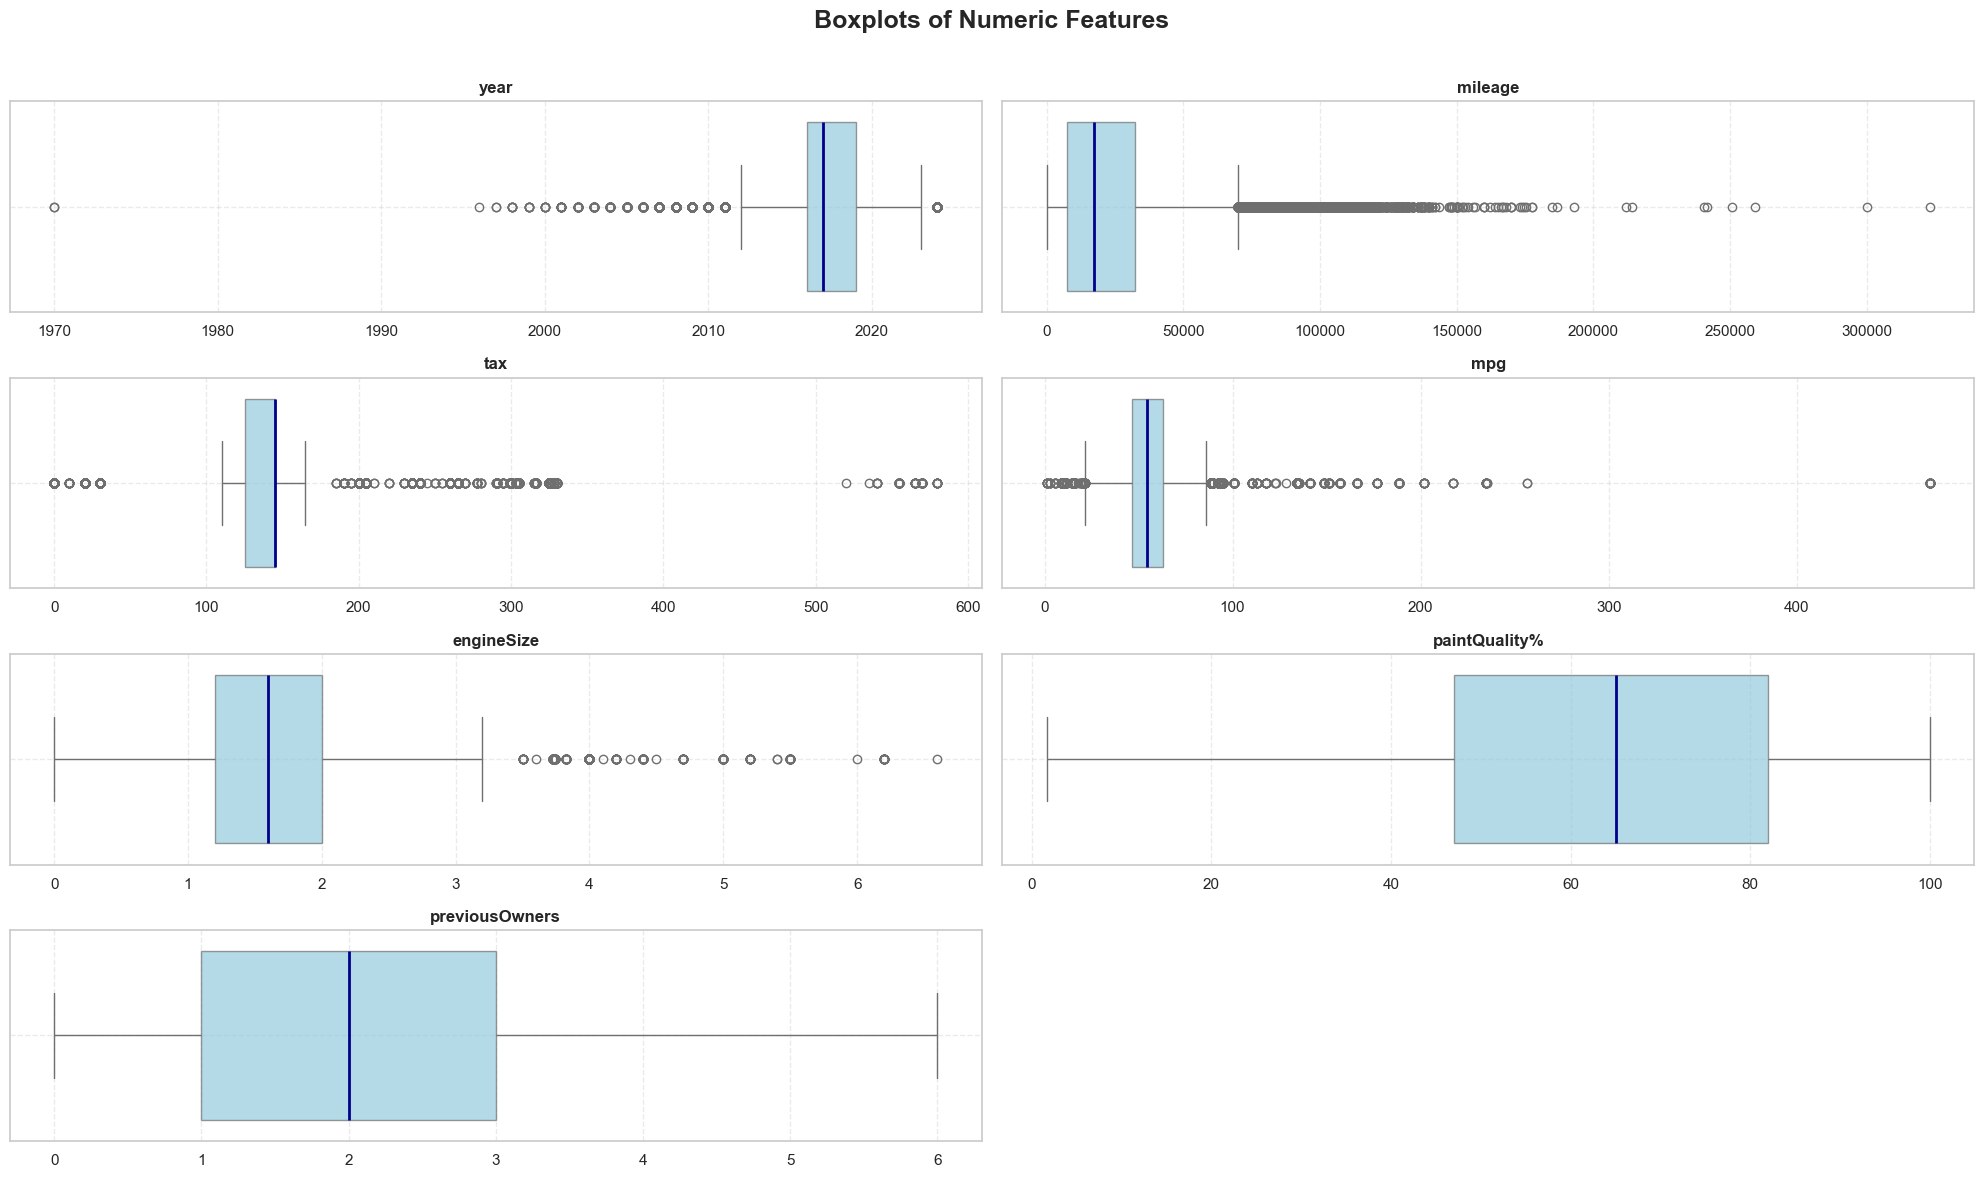

In [ ]:
sys.path.append("..") # add the parent directory to the system path

from recurrent_functions.create_boxplots import create_boxplots

create_boxplots(train, numeric_cols)

Now X_num has been cleaned of negative values and outliers in paintQuality%. After this we still observe some outliers that need to be treated. For this treatment we will create a function that implements the IQR method.

**Important:** Before applying the IQR method to treat outliers we need to split the data into train and validation sets. This is important to avoid data leakage. After splitting the data we can apply the IQR method using only the training set statistics.

<a class="anchor" id="5_4">

## **5.4** Data Partition

[Back to TOC](#toc)

Define the independent features as X and the dependent as Y

In [ ]:
X = train.drop('price', axis = 1)
y = train['price']

Split the dataset into train and validation

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(X,y, test_size = 0.2, 
                                                  random_state = 0, 
                                                  shuffle = True)

Numerical and Categorical columns

In this section we define two lists with the numerical and categorical columns for further use in the preprocessing steps 

In [ ]:
num_cols = ['year', 'mileage', 'tax', 'mpg', 'engineSize', 'paintQuality%', 'previousOwners']
cat_cols = ['Brand', 'model', 'transmission', 'fuelType', 'hasDamage']

<a class="anchor" id="5_5">

## **5.5** Continue Outliers Treatment

[Back to TOC](#toc)

After treating outliers with the IQR method, we realized it eliminated too much data, which then hurt the model's results and decided to create different thresholds specific for each feature. We still kept the code for the IQR method in markdown below. We set each thresholds for the following reasons:

- `year:` Cars older than 1990 were extremely rare and introduced high price variance, while years beyond 2025 are not possible; restricting the range improves data realism and model stability.
- `mileage:` Mileage has a strong right-skew; using a 2.2 IQR multiplier caps extreme values that disproportionately reduce accuracy without removing legitimate high-mileage cases.
- `tax:` Very high tax values occur infrequently and are often errors or special situations; applying a 2.0 IQR multiplier reduces the effect of unrealistic taxation outliers.
- `mpg:` Fuel efficiency extremes are uncommon and distort pricing; a 2.2 IQR multiplier tightens the distribution while preserving real variability across models.
- `engineSize:` Values below 0.9L or above 5.5L correspond to niche or erroneous entries; bounding engine size maintains realistic ranges and limits skew.
- `paintQuality%:` Paint condition cannot logically exceed 100% or go below 0%; enforcing natural bounds ensures data validity.
- `previousOwners:` More than 8 previous owners is highly atypical and signals noisy observations; capping reduces their undue influence on vehicle price.

In [ ]:
def treat_outliers_custom(df, col_thresholds):
    """
    Caps outliers per column based on custom IQR multipliers or manual bounds.
    """
    
    df_clean = df.copy()

    for col, rules in col_thresholds.items():
        # Compute quartiles and IQR
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1

        # Use IQR multiplier OR manual bounds
        if "iqr_mult" in rules:
            mult = rules['iqr_mult']
            lower = q1 - mult * iqr
            upper = q3 + mult * iqr
        else:
            lower = rules.get('lower', -np.inf)
            upper = rules.get('upper', np.inf)

        df_clean[col] = df_clean[col].clip(lower=lower, upper=upper)

    return df_clean


column_rules = {
    'year': {'lower': 1980, 'upper': 2025},
    'mileage': {'iqr_mult': 2.2},
    'tax': {'iqr_mult': 2.0},
    'mpg': {'iqr_mult': 2.2},
    'engineSize': {'lower': 0.9, 'upper': 5.5},
    'paintQuality%': {'lower': 0, 'upper': 100},
    'previousOwners': {'lower': 0, 'upper': 8}
}

In [ ]:
# IQR METHOD

# def treat_outliers(df, df_to_apply, num_cols, year_col='year'):
#     """Cap outliers in numeric columns of df_to_apply based on IQR calculated from df."""
#     # Select only numeric columns from the reference
#     df_numeric = df[num_cols]
    
#     # Calculate Q1, Q3 and IQR
#     q1 = df_numeric.quantile(0.25)
#     q3 = df_numeric.quantile(0.75)
#     iqr = q3 - q1

#     # Define lower and upper bounds
#     lower_bound = q1 - 1.5 * iqr
#     upper_bound = q3 + 1.5 * iqr

#     # Round bounds only for the year column
#     if year_col in num_cols:
#         lower_bound[year_col] = int(np.floor(lower_bound[year_col]))
#         upper_bound[year_col] = int(np.ceil(upper_bound[year_col]))

#     # Cap the outliers in df_to_apply
#     df_capped = df_to_apply.copy()
#     for col in num_cols:
#         df_capped[col] = df_capped[col].clip(lower=lower_bound[col], upper=upper_bound[col])

#     return df_capped

# X_train_copy = X_train.copy()

# X_train = treat_outliers(X_train_copy, X_train, num_cols)
# X_val = treat_outliers(X_train_copy, X_val, num_cols)
# test  = treat_outliers(X_train_copy, test, num_cols)

Apply custom thresholds

In [ ]:
X_train_copy = X_train.copy()

X_train = treat_outliers_custom(X_train, column_rules)
X_val = treat_outliers_custom(X_val, column_rules)
test  = treat_outliers_custom(test, column_rules)

Visualize boxplots one more time

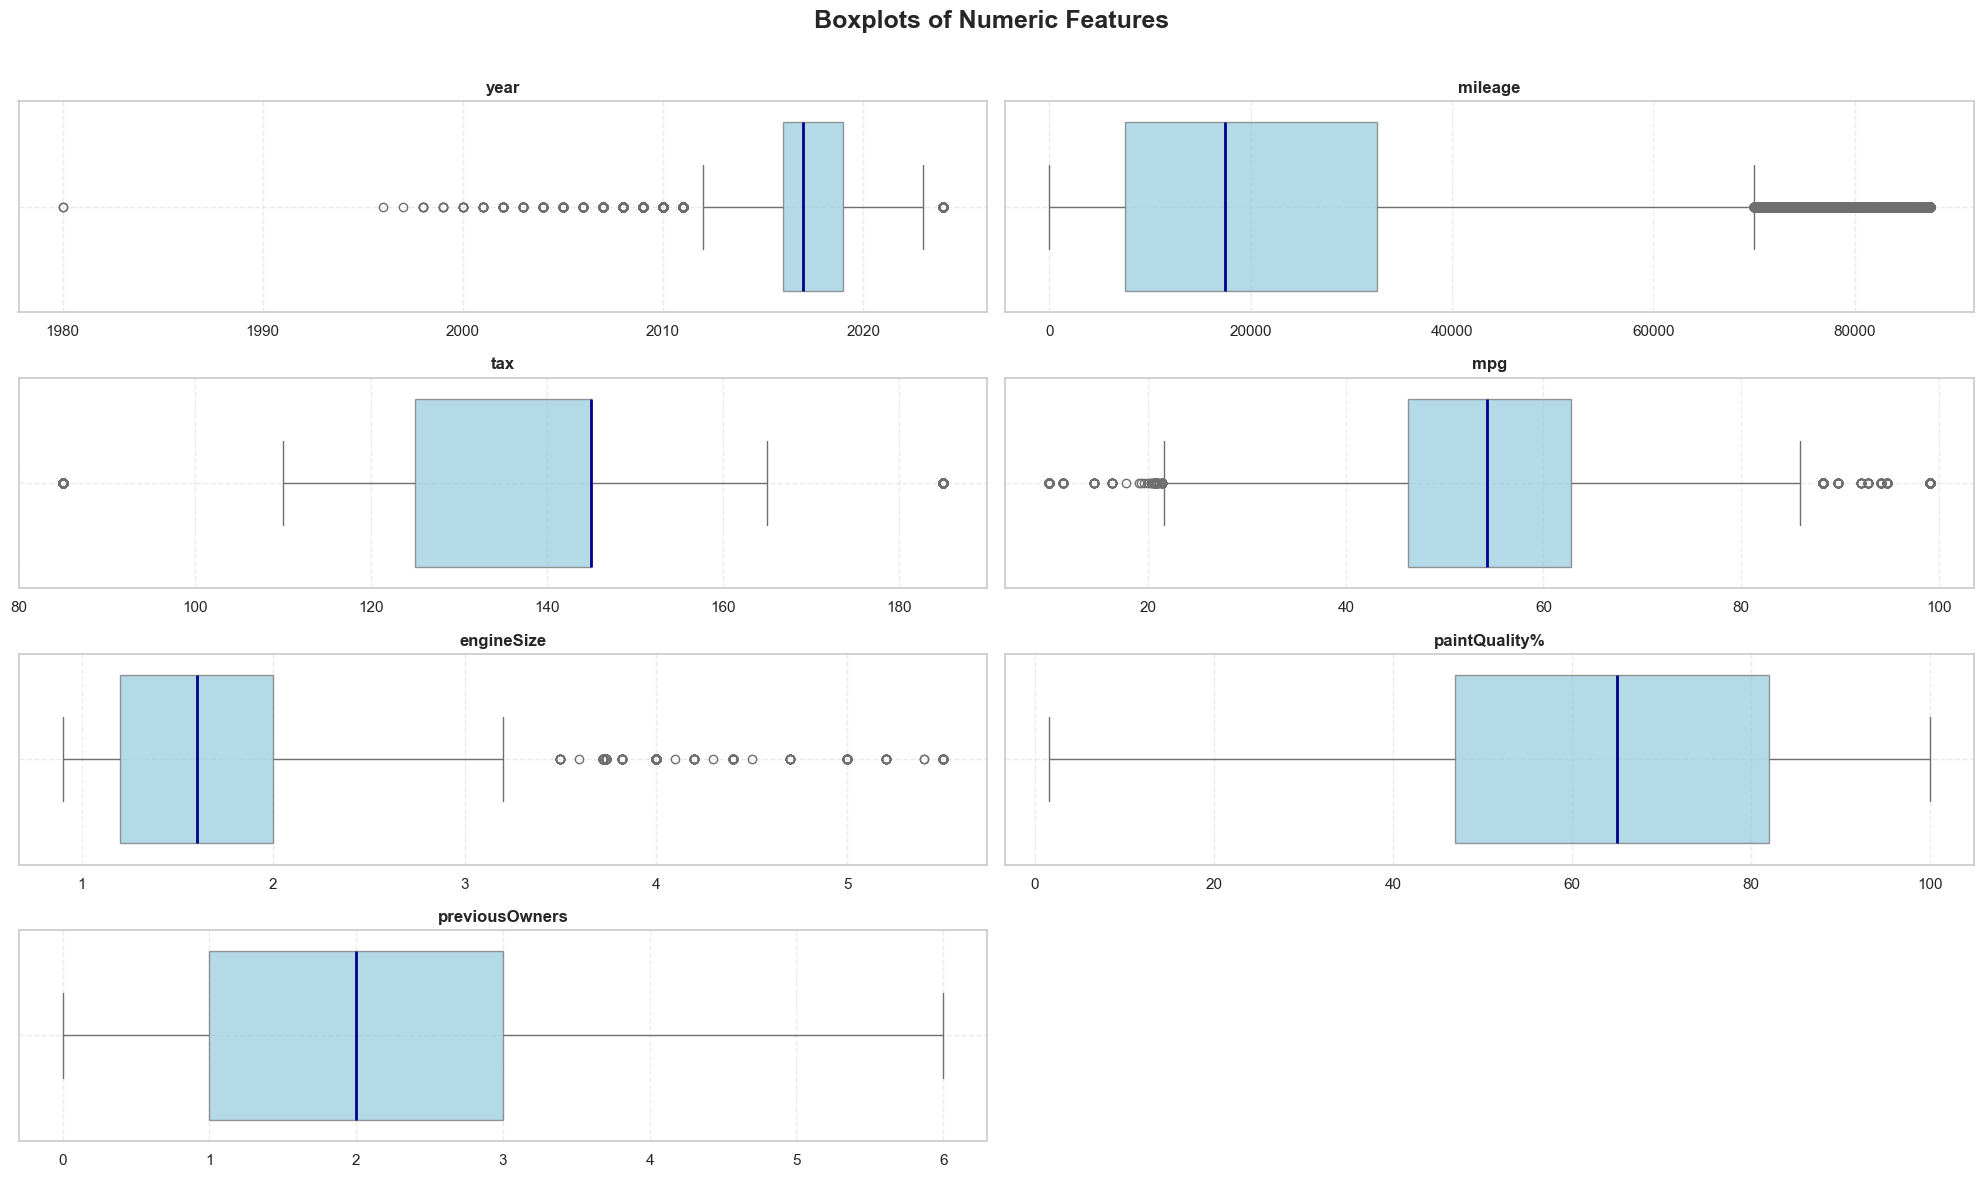

In [ ]:
sys.path.append("..") # add the parent directory to the system path

from recurrent_functions.create_boxplots import create_boxplots

create_boxplots(X_train, num_cols)

<a class="anchor" id="5_6">

## **5.6** Feature Engineering without using median, mean or mode

[Back to TOC](#toc)

On this step of the project we created new features that make sense and can help us predicting our target. For now the features that we want to add are:
 - `car_age:` calculate the age of the car considering the current year and the year of its registration. This feature helps us to capture depreciation, this is, older cars tend to be cheaper.

- `is_recent_car:` binary flag, 1 if the car is less than 3 years old, otherwise 0. We decided to create this feature because highlights newer cars, usually have higher resale prices.

- `mileage_category:` transforms the original continuous mileage feature into an ordered categorical feature with five usage levels according to the total mileage.  This way it's easier to capture differences in vehicle wear and market value.

- `is_hybrid_or_eletric:` binary indicator that is 1 if the fuel type is Hybrid or Electric. Eco-friendly cars often hold higher market value.

- `is_automatic:`binary indicator that is 1 if the type of transmission is automatic or semi-automatic. Automatics typically cost more to buy and maintain.

- `fuel_eficciency_score:` Ratio of mpg / engineSize. Captures how efficiently the car converts fuel given engine capacity.

- `tax_to_engine_ratio:` Tax value divided by engine size. Indicates how expensive it is to maintain the car relative to its power.

- `tax_efficency:` mpg / tax. Measures how fuel-efficient the car is relative to its yearly tax burden.

- `paint_quality_category:` Paint quality binned into Low, Medium, High.

- `has_damage_or_low_paint:` Binary flag, 1 if the car is damaged or has low paint quality (<40%). Combines visible and declared damage into a single condition indicator.

- `is_first_owner:` binary indicator that is 1 if there were no previous owners. First-owner cars tend to have less wear, better care and higher prices. **It was impossible to implement due to missing values**

- `ownership_ratio:` previousOwner / car_age. Captures how frequently ownership changed. Frequent changes might signal reliability issues.

To do this we'll implement some functions that help us defining this new features.

In [ ]:
def car_age_features(X, current_year=2020, threshold=3):
    """Calculate car age and flag recent cars."""
    X["car_age"] = current_year - X["year"]
    X["is_recent_car"] = (X["car_age"] <= threshold).astype('Int64')
    return X

def mileage_category(X):
    """Create categorical mileage bins."""
    bins = [0, 10_000, 50_000, 100_000, 150_000, float('inf')]
    labels = ['Very Low', 'Low', 'Medium', 'High', 'Very High']
    X['mileage_category'] = pd.cut(X['mileage'], bins=bins, labels=labels, include_lowest=True)
    return X

def fuel_transmission_features(X):
    """Binary flags for eco-friendly cars and automatic transmission."""
    X["is_hybrid_or_electric"] = X["fuelType"].isin(["Hybrid", "Electric"]).astype('Int64')
    X["is_automatic"] = X["transmission"].isin(["Automatic", "Semi-Auto"]).astype('Int64')
    X["fuel_efficiency_score"] = X["mpg"] / X["engineSize"].replace(0, np.nan)
    return X

def tax_and_efficiency_features(X):
    """Calculate economic indicators based on tax and engine size."""
    X["tax_to_engine_ratio"] = X["tax"] / X["engineSize"].replace(0, np.nan)
    X["tax_efficiency"] = X["mpg"] / X["tax"].replace(0, np.nan)
    return X

def condition_features(X):
    """Simplify paint quality and damage info."""
    X["paintQuality_category"] = pd.cut(X["paintQuality%"],
                                        bins=[0, 40, 70, 100],
                                        labels=["Low", "Medium", "High"])
    X["has_damage_or_low_paint"] = ((X["hasDamage"] == 1) | (X["paintQuality%"] < 40)).astype('Int64')
    return X

def ownership_features(X):
    """Ownership-related features."""
    X["is_first_owner"] = (X["previousOwners"] == 0).round().astype('Int64')
    return X

# --- Function to Apply All Feature Engineering Steps ---

def apply_feature_engineering(X):
    """
    Apply all feature engineering transformations in a pipeline using .pipe().
    This ensures code readability and consistent transformations.
    """
    return (X
            .pipe(car_age_features)
            .pipe(mileage_category)
            .pipe(fuel_transmission_features)
            .pipe(tax_and_efficiency_features)
            .pipe(condition_features)
            .pipe(ownership_features)
           )


In [ ]:
X_train_fe = apply_feature_engineering(X_train)
X_val_fe = apply_feature_engineering(X_val)
test_fe = apply_feature_engineering(test)

# Update dataframes to include new features
X_train = X_train_fe.copy()  
X_val = X_val_fe.copy()
test = test_fe.copy()

<a class="anchor" id="5_7">

## **5.7** Feature Engineering considering mean and other calculations

[Back to TOC](#toc)

On this step of the project we created new features that make sense and can help us predicting our target. To create these new features we need to do some calculations like median and average. Because of this we are creating them after the train-validation split to avoid data leakage

For now the features that we want to add are:

- `brand_median_mileage:` median mileage per brand. Typical mileage level for each brand that is able to capture brand usage patterns.

- `brand_avg_engineSize`: engineSize mean per brand. Represents typical engine capacity of each brand.

- `model_median_tax:` median tax per model. Captures model-specific taxation tendencies.

- `fueltype_avg_mpg:` mpg mean per fuelType. Average fuel efficiency for each fuel type.

- `brand_avg_age:` car_age mean per brand. Average car age per brand, basically compare newer against older brands.

To do this we'll implement some functions that help us defining this new features.

In [ ]:
# Create mapping dictionaries based on TRAIN data only 

# Calculate group statistics using only X_train
brand_median_mileage_map = X_train.groupby('Brand')['mileage'].median().to_dict()
brand_avg_engineSize_map = X_train.groupby('Brand')['engineSize'].mean().to_dict()
model_median_tax_map     = X_train.groupby('model')['tax'].median().to_dict()
fueltype_avg_mpg_map     = X_train.groupby('fuelType')['mpg'].mean().to_dict()
brand_avg_age_map        = X_train.groupby('Brand')['car_age'].mean().to_dict()


# Define a function to apply the mappings to any dataset

def apply_group_based_features(df):
    """Apply precomputed group-based features (from training data) to any dataframe."""

    # Map precomputed values from the training set
    df['brand_median_mileage'] = df['Brand'].map(brand_median_mileage_map)
    df['brand_avg_engineSize'] = df['Brand'].map(brand_avg_engineSize_map)
    df['model_median_tax']     = df['model'].map(model_median_tax_map)
    df['fueltype_avg_mpg']     = df['fuelType'].map(fueltype_avg_mpg_map)
    df['brand_avg_age']        = df['Brand'].map(brand_avg_age_map)

    return df


In [ ]:
#Apply mappings to training and validation sets
X_train_fe = apply_group_based_features(X_train)
X_val_fe   = apply_group_based_features(X_val)
test_fe    = apply_group_based_features(test)

# Update dataframes to include new features
X_train = X_train_fe.copy()  
X_val = X_val_fe.copy()
test = test_fe.copy()

<a class="anchor" id="5_8">

## **5.8** Missing Values

[Back to TOC](#toc)

<a class="anchor" id="5_8_1">

### **5.8.1** Missing Values Analysis

[Back to TOC](#toc)

Before starting to fill missing values, we assess the previously saved DataFrame with missing value percentages. With this we can easily identify columns with many absent entries and decide whether they are relevant for the model or should be discarded or imputed.

In [ ]:
# Import the missing values summary DataFrame
missing_df = pd.read_csv('../EDA_outputs/missing_values_summary.csv', index_col=0)
missing_df

,Feature,Missing_Percent
0,mpg,10.432654
1,tax,10.403696
2,previousOwners,2.040198
3,hasDamage,2.037566
4,paintQuality%,2.005976
5,transmission,2.003343
6,Brand,2.002027
7,model,1.996762
8,engineSize,1.995446
9,fuelType,1.988864


Although some features have missing values, none have a sufficiently high percentage to warrant removal. All columns are considered relevant and can be retained for modeling, with missing values handled through imputation where necessary.

Split features in different groups of missing values percentages.

In [ ]:
low_missing_values = missing_df[missing_df['Missing_Percent'] <= 5.0]['Feature'].tolist()
high_missing_values = missing_df[missing_df['Missing_Percent'] > 5.0]['Feature'].tolist()
print(low_missing_values)
print(high_missing_values)

['previousOwners', 'hasDamage', 'paintQuality%', 'transmission', 'Brand', 'model', 'engineSize', 'fuelType', 'year', 'mileage', 'price']
['mpg', 'tax']


In [ ]:
#Update num_cols features to include new numeric features
num_cols = ['year', 'mileage', 'tax', 'mpg', 'engineSize', 'paintQuality%', 'previousOwners',
                'car_age', 'fuel_efficiency_score', 'tax_to_engine_ratio', 'tax_efficiency',
                'brand_median_mileage', 'brand_avg_engineSize', 'model_median_tax',
                'fueltype_avg_mpg', 'brand_avg_age']
cat_cols = ['Brand', 'model', 'transmission', 'fuelType', 'hasDamage', 'is_recent_car', 'mileage_category',
            'is_hybrid_or_electric', 'is_automatic', 'paintQuality_category', 'has_damage_or_low_paint', 'is_first_owner']

Our approach to filling missing values will take into account the percentage of missing data for each feature and will be as follows:
- Features with a low percentage of missing values (<5%) will be imputed using simple methods such as mean, median, or mode. We chose this approach to prioritise simplicity and interpretability while not significantely biasing the model and assuming the data is missing completely at random.

- Features with a moderate percentage of missing values (5-20%) will be imputed carefully, possibly using more advanced methods such as KNN (if features have low correlation with the others).

<a class="anchor" id="5_8_2">

### **5.8.2** Treat Numeric Missing Values with the median

[Back to TOC](#toc)

First we fill the missing values with the median for the features with low percentage:

In [ ]:
for col in num_cols:
      # Check if the column has low or high missing values
    if col in low_missing_values:    
        median_value = X_train[col].median() # calculate median from training set
        X_train.loc[:, col] = X_train[col].fillna(median_value)
        X_val.loc[:, col] = X_val[col].fillna(median_value)
        test.loc[:, col] = test[col].fillna(median_value)

For the rest of the numeric features that have missing values we'll use the KNN imputer technique because there's a higher percentage of missing values. To use this technique we need to normalize the numeric values first using the MinMaxScaler function.

We will do this after enconding and sclaing all features.

<a class="anchor" id="5_8_3">

### **5.8.3** Treat Categorical Missing Values with the mode

[Back to TOC](#toc)

In [ ]:
for col in cat_cols:
    mode_value = X_train[col].mode()[0] # Get the most frequent value from training data

    # Fill missing values in both training and validation sets using the training mode
    X_train.loc[:, col] = X_train[col].fillna(mode_value)
    X_val.loc[:, col] = X_val[col].fillna(mode_value)
    test.loc[:, col] = test[col].fillna(mode_value)

Now we will check if there are any remaining missing values. It is important to remember that only missing values with low percentage were treated so it's normal to still have some features with missing values, but only the features with high percentage of them.

After the analysis that follows this reasoning is confirmed and now we only have 5 features with missing values: the features that we saw to have high percentage of missing values.

In [ ]:
X_train.isna().sum()

Brand                         0
model                         0
year                          0
transmission                  0
mileage                       0
fuelType                      0
tax                        6605
mpg                        6349
engineSize                    0
paintQuality%                 0
previousOwners                0
hasDamage                     0
car_age                    1198
is_recent_car                 0
mileage_category              0
is_hybrid_or_electric         0
is_automatic                  0
fuel_efficiency_score      7479
tax_to_engine_ratio        7724
tax_efficiency             7720
paintQuality_category         0
has_damage_or_low_paint       0
is_first_owner                0
brand_median_mileage       1211
brand_avg_engineSize       1211
model_median_tax           1184
fueltype_avg_mpg           1189
brand_avg_age              1211
dtype: int64

<a class="anchor" id="5_9">

## **5.9** Encoding

[Back to TOC](#toc)

Before training machine learning models, it is necessary to convert categorical features into a numerical format, as most algorithms cannot process non-numeric data directly. This step, known as encoding, ensures that the categorical information can be effectively interpreted by the models without losing its meaning.

In this section, we will apply `One-Hot Encoding` to features with a small number of categories (Brand, Transmission, fuelType) and use a `Ordinal Encoder` for the features that contains many distinct categories (model). This approach allows us to represent all categorical features in a consistent and efficient way, preparing the dataset for further preprocessing and model development.

In [ ]:
def encode_features(df, one_hot_cols=None, ordinal_cols=None):
    """
    Applies OneHotEncoding and OrdinalEncoding to specific columns of a DataFrame.
    
    Parameters:
        df (pd.DataFrame): Input DataFrame
        one_hot_cols (list): List of columns to apply OneHotEncoder
        ordinal_cols (list): List of columns to apply OrdinalEncoder    
    
    Returns: 
        df_encoded (pd.DataFrame): transformed DataFrame
    """
    
    df_encoded = df.copy()
    encoders = {}

    # -------- ORDINAL ENCODING --------
    if ordinal_cols:
        for col in ordinal_cols:
            le = OrdinalEncoder()
            df_encoded[col] = le.fit_transform(df_encoded[[col]])
            encoders[f"OrdinalEncoder_{col}"] = le # Store encoder for each column to apply later in test and validation sets

    # -------- ONE HOT ENCODING --------
    if one_hot_cols:
        ohe = OneHotEncoder(sparse_output=False, drop="first")
        ohe_array = ohe.fit_transform(df_encoded[one_hot_cols])

        ohe_df = pd.DataFrame(
            ohe_array,
            columns=ohe.get_feature_names_out(one_hot_cols),
            index=df_encoded.index
        )

        df_encoded = df_encoded.drop(columns=one_hot_cols)
        df_encoded = pd.concat([df_encoded, ohe_df], axis=1)

        encoders["OneHotEncoder"] = ohe

    return df_encoded


Unseen categorical levels were handled by fitting the OneHotEncoder only on the training set and using `handle_unknown='ignore'` to safely map new categories to zero-valued dummy vectors during validation and testing. This prevents data leakage and ensures robust model evaluation.

In [ ]:
# Define columns for encoding
label_cols_cat = X_train[['mileage_category', 'paintQuality_category']].columns.tolist()
one_hot_cols_cat = X_train[['Brand', 'model', 'transmission', 'fuelType']].columns.tolist()

In [ ]:
X_cat_train_copy = X_train[cat_cols].copy() #keep a copy of the original training categorical data for fitting the encoder

X_train = encode_features(X_train, one_hot_cols=one_hot_cols_cat, label_cols=label_cols_cat)
X_val = encode_features(X_val, one_hot_cols=one_hot_cols_cat, label_cols=label_cols_cat)
test = encode_features(test, one_hot_cols=one_hot_cols_cat, label_cols=label_cols_cat)

In [ ]:
X_val.columns.tolist()

['year',
 'mileage',
 'tax',
 'mpg',
 'engineSize',
 'paintQuality%',
 'previousOwners',
 'hasDamage',
 'car_age',
 'is_recent_car',
 'mileage_category',
 'is_hybrid_or_electric',
 'is_automatic',
 'fuel_efficiency_score',
 'tax_to_engine_ratio',
 'tax_efficiency',
 'paintQuality_category',
 'has_damage_or_low_paint',
 'is_first_owner',
 'brand_median_mileage',
 'brand_avg_engineSize',
 'model_median_tax',
 'fueltype_avg_mpg',
 'brand_avg_age',
 'Brand_BMW',
 'Brand_Ford',
 'Brand_Hyundai',
 'Brand_Mercedes',
 'Brand_Opel',
 'Brand_Skoda',
 'Brand_Toyota',
 'Brand_VW',
 'model_ 2 Series',
 'model_ 3 Serie',
 'model_ 3 Series',
 'model_ 4 Series',
 'model_ 5 Series',
 'model_ 6 Series',
 'model_ 7 Series',
 'model_ 8 Series',
 'model_ A Class',
 'model_ A1',
 'model_ A3',
 'model_ A4',
 'model_ A5',
 'model_ A6',
 'model_ A7',
 'model_ A8',
 'model_ Adam',
 'model_ Agila',
 'model_ Amarok',
 'model_ Antara',
 'model_ Arteon',
 'model_ Astra',
 'model_ Auris',
 'model_ Avensis',
 'model_

Before moving to the next step we need to update the list cat_cols because after enconding new columns were created.

In [ ]:
cat_cols = X_train.drop(num_cols, axis=1).columns.tolist()
cat_cols

['hasDamage',
 'is_recent_car',
 'mileage_category',
 'is_hybrid_or_electric',
 'is_automatic',
 'paintQuality_category',
 'has_damage_or_low_paint',
 'is_first_owner',
 'Brand_BMW',
 'Brand_Ford',
 'Brand_Hyundai',
 'Brand_Mercedes',
 'Brand_Opel',
 'Brand_Skoda',
 'Brand_Toyota',
 'Brand_VW',
 'model_ 2 Series',
 'model_ 3 Serie',
 'model_ 3 Series',
 'model_ 4 Series',
 'model_ 5 Series',
 'model_ 6 Series',
 'model_ 7 Series',
 'model_ 8 Series',
 'model_ A Class',
 'model_ A1',
 'model_ A2',
 'model_ A3',
 'model_ A4',
 'model_ A5',
 'model_ A6',
 'model_ A7',
 'model_ A8',
 'model_ Accent',
 'model_ Adam',
 'model_ Agila',
 'model_ Amarok',
 'model_ Ampera',
 'model_ Antara',
 'model_ Arteon',
 'model_ Astra',
 'model_ Auris',
 'model_ Avensis',
 'model_ Aygo',
 'model_ B Class',
 'model_ B-MAX',
 'model_ Beetle',
 'model_ C Class',
 'model_ C-HR',
 'model_ C-MAX',
 'model_ CC',
 'model_ CL Clas',
 'model_ CLS Class',
 'model_ Caddy',
 'model_ Caddy Life',
 'model_ Caddy Maxi',
 

<a class="anchor" id="5_10">

## **5.10** Scaling Features

[Back to TOC](#toc)

Numerical features are scaled to ensure all features are in a comparable scale. In this project, we use MinMaxScaler to transform features to a range between 0 and 1. This preserves relative relationships while preventing features with larger ranges from dominating distance or gradient based algorithms, improving model performance and stability.

In [ ]:
# Initialize scaler
scaler = StandardScaler()

# Fit only on training data
scaler.fit(X_train[num_cols])

# Transform and convert back to DataFrame (preserving column names and index)
X_train_scaled = pd.DataFrame(scaler.transform(X_train[num_cols]),
                              columns=num_cols,
                              index=X_train.index)

X_val_scaled = pd.DataFrame(scaler.transform(X_val[num_cols]),
                            columns=num_cols,
                            index=X_val.index)

test_scaled = pd.DataFrame(scaler.transform(test[num_cols]),
                           columns=num_cols,
                           index=test.index)


In [ ]:
X_train_scaled

,year,mileage,tax,mpg,engineSize,paintQuality%,previousOwners,car_age,fuel_efficiency_score,tax_to_engine_ratio,tax_efficiency,brand_median_mileage,brand_avg_engineSize,model_median_tax,fueltype_avg_mpg,brand_avg_age
carID,,,,,,,,,,,,,,,,
59459,-0.498972,0.332610,-1.668502,0.655177,-1.204080,-1.092520,-0.010534,0.494860,1.747557,-0.065385,1.449977,0.860983,-0.812248,-4.490998,-0.732932,0.866502
49082,-0.041248,1.952167,0.412874,0.768555,0.606157,-1.189960,0.692224,0.041661,-0.315296,-0.468270,-0.035443,-1.850102,-0.765444,0.181829,0.667170,-2.220372
14425,-4.160769,3.212952,1.800458,-1.013107,0.606157,-0.264280,-0.713291,4.120450,-1.054429,0.176345,-1.112391,1.021802,1.636282,0.181829,-0.732932,0.100643
13190,0.874201,-0.582862,0.412874,-0.195162,0.606157,0.369081,1.394981,-0.864736,-0.715100,-0.468270,-0.447201,1.021802,1.636282,0.181829,0.667170,0.100643
60655,0.874201,-1.023401,0.412874,-0.802547,-0.842033,0.807561,0.692224,-0.864736,0.036352,1.089550,-0.706712,0.860983,-0.812248,0.181829,-0.732932,0.866502
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47192,0.874201,-0.901955,0.412874,0.655177,-0.117938,1.489641,-0.713291,-0.864736,0.165141,0.115912,-0.083885,-1.850102,-0.765444,0.181829,0.667170,-2.220372
71813,-2.329871,3.212952,1.800458,-0.567691,0.606157,1.684521,0.692224,2.307655,-0.869646,0.176345,-0.963230,-0.678062,-0.181908,0.181829,0.667170,-0.843636
4910,0.874201,-1.051124,0.412874,-0.551494,-1.204080,1.343481,-0.010534,-0.864736,0.746368,1.868459,-0.599447,1.220480,0.914606,-4.490998,-0.732932,-0.039681


<a class="anchor" id="5_11">

## **5.11** KNN Imputer

[Back to TOC](#toc)

In [ ]:
# Initialize KNN imputer
knn_imputer = KNNImputer(n_neighbors=5)

# Fit the imputer only on the training data to avoid data leakage
knn_imputer.fit(X_train_scaled)

# Apply the imputer to all splits
X_train_imputed = pd.DataFrame(knn_imputer.transform(X_train_scaled),
                               columns=num_cols,
                               index=X_train_scaled.index)

X_val_imputed = pd.DataFrame(knn_imputer.transform(X_val_scaled),
                             columns=num_cols,
                             index=X_val_scaled.index)

test_imputed = pd.DataFrame(knn_imputer.transform(test_scaled),
                            columns=num_cols,
                            index=test_scaled.index)

In [ ]:
X_train_final = pd.concat([X_train_imputed, X_train[cat_cols]], axis=1)
X_val_final   = pd.concat([X_val_imputed, X_val[cat_cols]], axis=1)
test_final    = pd.concat([test_imputed, test[cat_cols]], axis=1)

Finally we correct all missing values and after we will check the total of missing values for the entire dataset to verify if we succeeded.

In [ ]:
X_train_final.isna().sum().sum()

np.int64(0)

In [ ]:
X_train.head().T

carID,59459,49082,14425,13190,60655
year,2016,2017,2008,2019,2019
mileage,29601.0,62140.0,87470.8,11208.0,2357.0
tax,85.0,145.0,185.0,145.0,145.0
mpg,62.8,64.2,42.2,52.3,44.8
engineSize,1.0,2.0,2.0,2.0,1.2
...,...,...,...,...,...
is_automatic_1.0,0.0,0.0,1.0,1.0,0.0
paintQuality_category_Low,0.0,1.0,0.0,0.0,0.0
paintQuality_category_Medium,1.0,0.0,1.0,0.0,0.0
has_damage_or_low_paint_1.0,0.0,0.0,0.0,0.0,0.0


<a class="anchor" id="5_12">

## **5.12** Save the Processed Data

[Back to TOC](#toc)

In [ ]:
# Go one level up from the notebooks folder to reach the repo root
processed_dir = "../data_preprocessed"
os.makedirs(processed_dir, exist_ok=True)

# Save processed datasets as CSV files
X_train_final.to_csv(f"{processed_dir}/X_train_preprocessed.csv", index=True)
X_val_final.to_csv(f"{processed_dir}/X_val_preprocessed.csv", index=True)
test_final.to_csv(f"{processed_dir}/test_preprocessed.csv", index=True)

y_train.to_csv(f"{processed_dir}/y_train.csv", index=True)
y_val.to_csv(f"{processed_dir}/y_val.csv", index=True)

<a class="anchor" id="6">

# **6** End of The Notebook

[Back to TOC](#toc)

From the data preprocessing stage, we ensured that the dataset was properly cleaned and transformed to be ready for modeling. Data inconsistencies were corrected, outliers were treated, missing values were handled, categorical variables were encoded and numerical features were scaled. As a result, the dataset is now more consistent, structured, and suitable for the application of machine learning algorithms. These preprocessing steps provide a solid foundation for the upcoming phases of feature selection and model development.